# Experimento 2 — Texto completo + final de la reseña

Clasificación de sentimiento de reseñas — Parte 1 (ML clásico). Aprendizaje de Máquina 2026-20, Universidad de los Andes.

Este notebook continúa `experimento1.ipynb`. Para que sea autocontenido, la sección 1 repite **de forma resumida**
la configuración común: carga de datos, normalización del texto, split train/test, validación cruzada y funciones
auxiliares. Se usan **la misma semilla y el mismo split**, de modo que los resultados son directamente comparables
con los del experimento 1. La exploración de datos y la justificación de cada paso de preprocesamiento están en
`experimento1.ipynb` (secciones 1 y 2).

El experimento 1 **no se vuelve a ejecutar** aquí: sus métricas se toman de `experimento1.ipynb` (línea base
TF-IDF (1,2) + LR, con `C = 10` elegido por su propia CV) y se registran como valores fijos de referencia.

**Contenido**
1. Configuración común (resumen)
2. Experimento 2 — Texto completo + final de la reseña

## 1. Configuración común (resumen)

### 1.1 Librerías, semilla y datos

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.base import clone

SEED = 42
np.random.seed(SEED)

CLASES = ["negativo", "neutral", "positivo"]

pd.set_option("display.max_colwidth", 200)
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.axisbelow": True,
})

train = pd.read_csv("train.csv").copy()
eval_df = pd.read_csv("eval.csv").copy()
sample_submission = pd.read_csv("sample_submission.csv")
conteo = train["label"].value_counts().reindex(CLASES)

print("train:", train.shape, "| eval:", eval_df.shape)

train: (12000, 3) | eval: (3000, 2)


### 1.2 Normalización base

La misma función de `experimento1.ipynb` (sección 2): reparar mojibake, minúsculas, quitar tildes conservando la ñ,
reducir letras repetidas 3+ veces a 2 y colapsar espacios. Conserva stopwords y puntuación.

In [2]:
TILDES = str.maketrans("áéíóúàèìòùäëïöüâêîôû", "aeiouaeiouaeiouaeiou")
PATRON_MOJIBAKE = re.compile(r"Ã[\x80-\xbf]")
PATRON_REPETIDAS = re.compile(r"([a-zñ])\1{2,}")


def reparar_mojibake(texto):
    return PATRON_MOJIBAKE.sub(lambda m: m.group().encode("latin-1").decode("utf-8"), texto)


def normalizar_texto(texto):
    texto = reparar_mojibake(texto)
    texto = texto.lower()
    texto = texto.translate(TILDES)
    texto = PATRON_REPETIDAS.sub(r"\1\1", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


train["text_norm"] = train["text"].map(normalizar_texto)
eval_df["text_norm"] = eval_df["text"].map(normalizar_texto)

### 1.3 Validación y métricas

Split 80/20 estratificado (el 20 % es el test hold-out, que solo se reporta) y CV estratificada de 5 folds sobre el
80 %. Se decide con accuracy (métrica de Kaggle) y se reporta F1 macro como control.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    train["text_norm"], train["label"], test_size=0.20, stratify=train["label"], random_state=SEED
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = {"accuracy": "accuracy", "f1_macro": "f1_macro"}

print(f"Entrenamiento + validación: {len(X_train):,}  |  Test: {len(X_test):,}")

Entrenamiento + validación: 9,600  |  Test: 2,400


### 1.4 Funciones auxiliares

Las mismas de `experimento1.ipynb` (sección 3.2 y 4.3).

In [4]:
# Métricas del experimento 1 tomadas de experimento1.ipynb (no se vuelve a ejecutar aquí)
REFERENCIA_E1 = {
    "experimento": 1,
    "descripcion": "Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",
    "mejores_params": {"clf__C": 10},
    "acc_train": 0.9973,
    "acc_cv": 0.7364,
    "std_cv": 0.0128,
    "f1_cv": 0.7478,
    "acc_test": 0.7238,
    "f1_test": 0.7366,
    "envio": "submission_01.csv",
    "kaggle_publico": None,
    "acc_neg_vs_pos_test": 0.607,
}

resultados = [{k: v for k, v in REFERENCIA_E1.items() if k != "acc_neg_vs_pos_test"}]


def contiene(serie, patron):
    """Serie booleana: True si el texto contiene el patrón."""
    return serie.map(lambda t: re.search(patron, t) is not None)


def tabla_cv(busqueda):
    """Resultados de un GridSearchCV ordenados por accuracy de validación."""
    cv = pd.DataFrame(busqueda.cv_results_)
    tabla = pd.DataFrame({
        "params": cv["params"],
        "acc_train": cv["mean_train_accuracy"],
        "acc_cv": cv["mean_test_accuracy"],
        "std_cv": cv["std_test_accuracy"],
        "f1_cv": cv["mean_test_f1_macro"],
        "seg_ajuste": cv["mean_fit_time"],
    })
    return tabla.sort_values("acc_cv", ascending=False).round(4)


def evaluar_en_test(modelo, titulo):
    """Accuracy, F1 macro, reporte por clase y matriz de confusión sobre el test (hold-out)."""
    pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average="macro")
    print(f"Test -> accuracy: {acc:.4f} | F1 macro: {f1:.4f}\n")
    print(classification_report(y_test, pred, labels=CLASES, digits=3))

    fig, ax = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=CLASES, cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(f"Matriz de confusión en test\n{titulo}")
    ax.set_xlabel("Clase predicha")
    ax.set_ylabel("Clase real")
    ax.grid(False)
    plt.show()
    return {"acc_test": acc, "f1_test": f1, "pred": pred}


def registrar_resultado(experimento, descripcion, busqueda, metricas_test, envio=None, kaggle_publico=None):
    """Agrega a la tabla de resultados el mejor modelo de un GridSearchCV."""
    i = busqueda.best_index_
    cv = busqueda.cv_results_
    resultados.append({
        "experimento": experimento,
        "descripcion": descripcion,
        "mejores_params": busqueda.best_params_,
        "acc_train": round(cv["mean_train_accuracy"][i], 4),
        "acc_cv": round(cv["mean_test_accuracy"][i], 4),
        "std_cv": round(cv["std_test_accuracy"][i], 4),
        "f1_cv": round(cv["mean_test_f1_macro"][i], 4),
        "acc_test": round(metricas_test["acc_test"], 4),
        "f1_test": round(metricas_test["f1_test"], 4),
        "envio": envio,
        "kaggle_publico": kaggle_publico,
    })
    return pd.DataFrame(resultados)


def generar_envio(busqueda, numero):
    """Reentrena la mejor configuración con las 12.000 reseñas, predice eval y guarda envío y modelo."""
    modelo = clone(busqueda.best_estimator_)
    modelo.fit(train["text_norm"], train["label"])

    envio = pd.DataFrame({"id": eval_df["id"], "answer": modelo.predict(eval_df["text_norm"])})

    assert list(envio.columns) == ["id", "answer"]
    assert len(envio) == len(sample_submission) == 3000
    assert set(envio["id"]) == set(sample_submission["id"])
    assert set(envio["answer"]) <= set(CLASES)

    Path("envios").mkdir(exist_ok=True)
    Path("modelos").mkdir(exist_ok=True)
    ruta_envio = f"envios/submission_{numero:02d}.csv"
    ruta_modelo = f"modelos/modelo_{numero:02d}.joblib"
    envio.to_csv(ruta_envio, index=False)
    joblib.dump(modelo, ruta_modelo)

    print(f"Envío guardado en {ruta_envio} y modelo en {ruta_modelo}")
    print("Distribución de predicciones en eval (%):")
    print((envio["answer"].value_counts(normalize=True).reindex(CLASES) * 100).round(1).to_string())
    return envio


def top_coeficientes(modelo, n=15):
    """N-gramas con mayor coeficiente por clase."""
    nombres = modelo.named_steps["tfidf"].get_feature_names_out()
    clf = modelo.named_steps["clf"]
    tabla = {}
    for k, clase in enumerate(clf.classes_):
        orden = clf.coef_[k].argsort()[::-1][:n]
        tabla[clase] = [f"{nombres[i]} ({clf.coef_[k][i]:.2f})" for i in orden]
    return pd.DataFrame(tabla)[CLASES]

## 2. Experimento 2 — Texto completo + final de la reseña

**Motivación:** el experimento 1 resolvió `neutral`, pero entre `negativo` y `positivo` acertó solo el 60,7 %. Ambas
clases contienen elogios y quejas, y la bolsa de palabras del texto completo no sabe cuál de las opiniones define el
sentimiento global.

**Hipótesis:** el veredicto está en una posición concreta de la reseña (según el enunciado, el orden y los conectores
contrastivos lo determinan). Si se identifica esa parte y se le da su propia representación, el modelo debería
separar mucho mejor `negativo` de `positivo`.

**Proceso:**
1. Segmentar cada reseña en oraciones.
2. Diagnóstico: entrenar el mismo modelo de la línea base usando **solo una parte** de la reseña (primera oración,
   texto completo, lo que sigue al último conector, última oración) para localizar dónde está el veredicto.
3. Combinar las partes más informativas con el texto completo, cada una con su propio TF-IDF, y comparar
   combinaciones (incluida una comparación fold por fold para verificar que la mejora no es ruido).
4. Ajustar `C` para la mejor combinación, evaluar en test y enviar.

### 2.1 Segmentación en oraciones

Se divide cada reseña por los signos `.`, `!`, `?` y `;` seguidos de espacio. La normalización base conserva la
puntuación justamente para poder hacer esta separación.

In [5]:
PATRON_ORACIONES = re.compile(r"(?<=[.!?;])\s+")


def dividir_oraciones(texto):
    """Lista de oraciones de un texto normalizado."""
    oraciones = [o.strip() for o in PATRON_ORACIONES.split(texto) if o.strip()]
    return oraciones or [texto]


n_oraciones = X_train.map(lambda t: len(dividir_oraciones(t)))
print("Oraciones por reseña:")
display(n_oraciones.describe().round(2).to_frame().T)

print("Ejemplo:")
for i, oracion in enumerate(dividir_oraciones(X_train.iloc[0]), start=1):
    print(f"  {i}. {oracion}")

Oraciones por reseña:


,count,mean,std,min,25%,50%,75%,max
text_norm,9600.0,3.9,0.77,1.0,4.0,4.0,4.0,7.0


Ejemplo:
  1. lo compre hace un par de meses por internet y llego en tres dias.
  2. desde que llego lo uso para el gimnasio.
  3. la carga se hace con un conector magnetico por un puerto propio.
  4. por cierto, trae garantia de un año.


### 2.2 Diagnóstico: ¿en qué parte de la reseña está el veredicto?

Se entrena el mismo pipeline de la línea base (TF-IDF (1,2) + LR, con `C = 3` fijo para comparar en igualdad de
condiciones) usando cada vez **una sola parte** de la reseña. Se reporta la accuracy de CV en las tres clases y,
aparte, restringida a las reseñas `negativo`/`positivo`, que es donde está el problema.

Para "tras el último conector" se toma el texto desde el último conector contrastivo encontrado; si la reseña no
tiene ninguno, se usa la última oración.

In [6]:
CONECTORES = (
    r"\b(pero|aunque|sin embargo|aun asi|en cambio|por otro lado|al final|en fin|eso si|"
    r"no obstante|de todas formas|con todo|ahora bien)\b"
)


def primera_oracion(texto):
    return dividir_oraciones(texto)[0]


def ultima_oracion(texto):
    return dividir_oraciones(texto)[-1]


def tras_ultimo_conector(texto):
    coincidencias = list(re.finditer(CONECTORES, texto))
    return texto[coincidencias[-1].start():] if coincidencias else ultima_oracion(texto)


def pipeline_base(C=3):
    return Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
        ("clf", LogisticRegression(C=C, max_iter=2000, random_state=SEED)),
    ])


PARTES = {
    "Primera oración": primera_oracion,
    "Texto completo (exp. 1)": lambda t: t,
    "Tras el último conector": tras_ultimo_conector,
    "Última oración": ultima_oracion,
}

mascara_np = (y_train != "neutral").to_numpy()
filas = []
for nombre, extraer in PARTES.items():
    X_parte = X_train.map(extraer)
    acc_3 = cross_val_score(pipeline_base(), X_parte, y_train, cv=skf, n_jobs=-1)
    acc_np = cross_val_score(pipeline_base(), X_parte[mascara_np], y_train[mascara_np], cv=skf, n_jobs=-1)
    filas.append({"parte usada": nombre, "acc_cv (3 clases)": acc_3.mean(), "std": acc_3.std(),
                  "acc_cv (negativo vs positivo)": acc_np.mean()})

diagnostico = pd.DataFrame(filas).round(4)
diagnostico

,parte usada,acc_cv (3 clases),std,acc_cv (negativo vs positivo)
0,Primera oración,0.5130,0.0138,0.5336
1,Texto completo (exp. 1),0.7363,0.0133,0.6269
2,Tras el último conector,0.8585,0.0071,0.8377
3,Última oración,0.8531,0.0104,0.8310


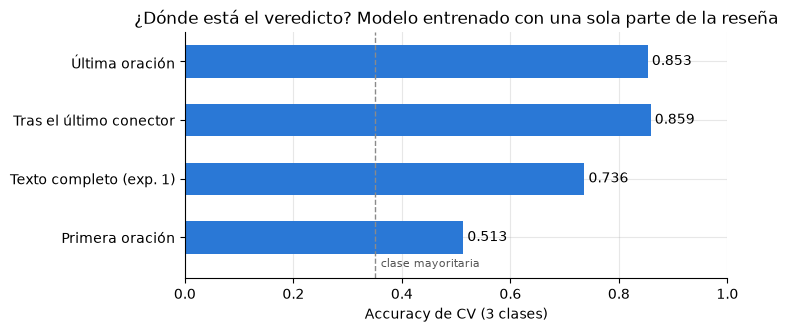

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.2))
barras = ax.barh(diagnostico["parte usada"], diagnostico["acc_cv (3 clases)"], color="#2a78d6", height=0.55)
ax.bar_label(barras, fmt="%.3f", padding=3)
ax.axvline(conteo.max() / conteo.sum(), color="#8a8a8a", linestyle="--", linewidth=1)
ax.annotate("clase mayoritaria", xy=(conteo.max() / conteo.sum(), -0.45), xytext=(4, 0),
            textcoords="offset points", fontsize=8, color="#555555", va="center")
ax.set_ylim(len(diagnostico) - 0.5, -0.7)
ax.set_xlim(0, 1)
ax.set_xlabel("Accuracy de CV (3 clases)")
ax.set_title("¿Dónde está el veredicto? Modelo entrenado con una sola parte de la reseña")
ax.invert_yaxis()
plt.show()

**Lectura del diagnóstico**

- La **primera oración** casi no tiene información: suele ser relleno sobre la compra y el envío.
- La **última oración** y el **fragmento tras el último conector**, usados solos, superan ampliamente al texto
  completo (≈ 0,85–0,86 frente a 0,736), sobre todo entre `negativo` y `positivo`. El veredicto global está al final
  de la reseña; al mezclarlo en una sola bolsa con el resto del texto, se diluye entre opiniones parciales de signo
  contrario.
- La diferencia entre ambas formas de cortar el final (≈ 0,005) es menor que la desviación entre folds: localizan el
  veredicto igual de bien. Son complementarias: cortar por oración no depende de una lista de conectores hecha a
  mano, y cortar por conector captura veredictos que no coinciden exactamente con la última oración.

Conclusión: el veredicto está **al final** de la reseña. Falta ver qué combinación de estas partes, junto con el
texto completo (que aporta, por ejemplo, la información que identifica a `neutral`), funciona mejor.

### 2.3 Combinaciones: cada parte con su propio TF-IDF

Se construye una tabla con varias partes de cada reseña y se vectoriza cada parte con un TF-IDF independiente
(`ColumnTransformer`); los vectores se concatenan. Así una misma palabra tiene **un peso distinto según su
posición**: `decepciono` en la última oración puede pesar mucho más que en el resto del texto.

La separación en partes se hace con un `FunctionTransformer` dentro del pipeline, de modo que el modelo recibe el
texto normalizado tal cual y el archivo de envío y el modelo guardado funcionan igual que en el experimento 1.
Para cada combinación se ajusta `C` ∈ {1, 3, 10}.

In [8]:
def separar_partes(textos):
    """DataFrame con distintas partes de cada reseña, para vectorizarlas por separado."""
    oraciones = [dividir_oraciones(t) for t in textos]
    return pd.DataFrame({
        "texto": list(textos),
        "ultima": [o[-1] for o in oraciones],
        "tras_conector": [tras_ultimo_conector(t) for t in textos],
        "penultima": [o[-2] if len(o) > 1 else "" for o in oraciones],
        "antepenultima": [o[-3] if len(o) > 2 else "" for o in oraciones],
        "sin_ultima": [" ".join(o[:-1]) for o in oraciones],
        "sin_ultimas_3": [" ".join(o[:-3]) for o in oraciones],
    })


def pipeline_partes(columnas, C=3):
    """Pipeline: separar partes -> un TF-IDF por parte -> regresión logística."""
    return Pipeline([
        ("partes", FunctionTransformer(separar_partes)),
        ("tfidf", ColumnTransformer([
            (col, TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True), col) for col in columnas
        ])),
        ("clf", LogisticRegression(C=C, max_iter=3000, random_state=SEED)),
    ])


separar_partes(X_train.head(2))

,texto,ultima,tras_conector,penultima,antepenultima,sin_ultima,sin_ultimas_3
0,"lo compre hace un par de meses por internet y llego en tres dias. desde que llego lo uso para el gimnasio. la carga se hace con un conector magnetico por un puerto propio. por cierto, trae garanti...","por cierto, trae garantia de un año.","por cierto, trae garantia de un año.",la carga se hace con un conector magnetico por un puerto propio.,desde que llego lo uso para el gimnasio.,lo compre hace un par de meses por internet y llego en tres dias. desde que llego lo uso para el gimnasio. la carga se hace con un conector magnetico por un puerto propio.,lo compre hace un par de meses por internet y llego en tres dias.
1,"hace unos dias, lo uso a diario. la verdad, el material me reslto optimo la verdad. con todo, el material se ve defectuoso la verdad.","con todo, el material se ve defectuoso la verdad.","con todo, el material se ve defectuoso la verdad.","la verdad, el material me reslto optimo la verdad.","hace unos dias, lo uso a diario.","hace unos dias, lo uso a diario. la verdad, el material me reslto optimo la verdad.",


In [9]:
COMBINACIONES = {
    "texto completo + última": ["texto", "ultima"],
    "texto completo + tras el último conector": ["texto", "tras_conector"],
    "texto completo + última + tras el último conector": ["texto", "ultima", "tras_conector"],
    "sin la última + última": ["sin_ultima", "ultima"],
    "texto completo + última + penúltima": ["texto", "ultima", "penultima"],
    "últimas 3 por separado + resto": ["ultima", "penultima", "antepenultima", "sin_ultimas_3"],
}

filas = []
busquedas_comb = {}
for nombre, columnas in COMBINACIONES.items():
    busqueda = GridSearchCV(pipeline_partes(columnas), {"clf__C": [1, 3, 10]}, cv=skf,
                            scoring=SCORING, refit="accuracy", n_jobs=-1)
    busqueda.fit(X_train, y_train)
    busquedas_comb[nombre] = busqueda
    i = busqueda.best_index_
    filas.append({
        "combinación": nombre,
        "mejor C": busqueda.best_params_["clf__C"],
        "acc_cv": busqueda.cv_results_["mean_test_accuracy"][i],
        "std_cv": busqueda.cv_results_["std_test_accuracy"][i],
        "f1_cv": busqueda.cv_results_["mean_test_f1_macro"][i],
    })

combinaciones = pd.DataFrame(filas).sort_values("acc_cv", ascending=False).round(4)
combinaciones

,combinación,mejor C,acc_cv,std_cv,f1_cv
2,texto completo + última + tras el último conector,10,0.8865,0.0099,0.8908
1,texto completo + tras el último conector,10,0.8777,0.0108,0.8827
0,texto completo + última,10,0.8771,0.0136,0.8821
3,sin la última + última,3,0.8758,0.0185,0.8808
4,texto completo + última + penúltima,10,0.8668,0.0144,0.8727
5,últimas 3 por separado + resto,10,0.8590,0.0110,0.8650


**¿La mejora de la combinación de tres partes es real?** Como todas las combinaciones se evalúan con los
**mismos 5 folds**, se pueden comparar fold por fold. Si la mejor combinación gana en todos los folds, la mejora es
consistente y no un efecto del ruido entre particiones.

In [10]:
def acc_por_fold(busqueda):
    i = busqueda.best_index_
    return np.array([busqueda.cv_results_[f"split{k}_test_accuracy"][i] for k in range(skf.get_n_splits())])


a = acc_por_fold(busquedas_comb["texto completo + última + tras el último conector"])
b = acc_por_fold(busquedas_comb["texto completo + última"])
pd.DataFrame({
    "texto + última + tras conector": a,
    "texto + última": b,
    "diferencia": a - b,
}, index=[f"fold {k}" for k in range(1, 6)]).round(4)

,texto + última + tras conector,texto + última,diferencia
fold 1,0.8938,0.8849,0.0089
fold 2,0.8734,0.8688,0.0047
fold 3,0.8984,0.8891,0.0094
fold 4,0.8906,0.8885,0.0021
fold 5,0.8760,0.8542,0.0219


**Lectura de las combinaciones**

- **Texto completo + última oración + tras el último conector** es la mejor combinación, con la accuracy más alta y
  la menor desviación entre folds, y supera a "texto completo + última" en cada uno de los folds.
- Las combinaciones de dos partes (texto + última, texto + tras conector) quedan prácticamente empatadas entre sí y
  por encima de cada parte sola: el texto completo aporta contexto (el vocabulario descriptivo de `neutral`,
  opiniones previas) y la parte final, con sus propios pesos, aporta el veredicto.
- Usar "sin la última" en lugar del texto completo da prácticamente lo mismo.
- **Agregar más posiciones de oraciones empeora:** la penúltima y antepenúltima suman miles de features con poca
  información adicional.

Se elige **texto completo + última oración + tras el último conector** para el experimento 2.

### 2.4 ¿Es razonable este supuesto? Leakage y generalización

**¿Hay fuga de información?** No. La última oración y el fragmento tras el último conector son parte de la entrada
(**X**), no de la etiqueta: cada reseña de eval también los tiene, disponibles al momento de predecir.
`separar_partes()` corta cada texto por su puntuación y por una lista fija de conectores, sin usar etiquetas ni
estadísticas del conjunto, y lo que sí se aprende (vocabulario e IDF de cada parte)
se ajusta dentro del `Pipeline`, solo con los datos de entrenamiento de cada fold. Además, toda la elección del
diseño (secciones 2.2 y 2.3) se hizo con CV sobre `X_train`; el test no participó.

**¿Reduce la generalización asumir que el veredicto está al final?** Es un supuesto, pero suave y respaldado:
- No se reemplaza el texto completo, se **agregan** las partes finales con sus propios pesos. Si en una reseña la
  última oración es relleno, sus features pesan poco y decide el texto completo. El modelo aprende de los datos
  cuánto peso darle a cada posición.
- Toda representación asume algo. La bolsa de palabras del experimento 1 asumía que **el orden no importa**, un
  supuesto mucho más fuerte y falso en este problema. El enunciado indica explícitamente que el sentimiento depende
  del orden de las cláusulas (**recencia**, negación, conectores).
- La CV, que mide el desempeño en datos no vistos, sube de forma clara.

**Límite:** el supuesto solo es válido si eval tiene la misma estructura que train. Se comprueba a continuación usando
únicamente los textos de eval (sin etiquetas, que no existen). Si el modelo se aplicara a reseñas de otra fuente,
con otra forma de escribir, esta ventaja podría no trasladarse.

In [11]:
def estructura(textos):
    oraciones = textos.map(dividir_oraciones)
    ultimas = oraciones.map(lambda o: o[-1])
    return {
        "oraciones por reseña (media)": oraciones.map(len).mean(),
        "% con 4 oraciones": (oraciones.map(len) == 4).mean() * 100,
        "palabras en la primera oración": oraciones.map(lambda o: len(o[0].split())).mean(),
        "palabras en la última oración": ultimas.map(lambda o: len(o.split())).mean(),
        "% última oración que contiene un conector": contiene(ultimas, CONECTORES).mean() * 100,
    }

pd.DataFrame({"train": estructura(train["text_norm"]), "eval": estructura(eval_df["text_norm"])}).round(2)

,train,eval
oraciones por reseña (media),3.90,3.90
% con 4 oraciones,59.00,57.33
palabras en la primera oración,16.47,16.67
palabras en la última oración,12.07,12.17
% última oración que contiene un conector,32.57,33.30


Train y eval tienen la misma estructura de oraciones, así que el supuesto es aplicable a los datos que se van a
predecir.

### 2.5 Modelo del experimento 2

Pipeline: `separar_partes` → TF-IDF del texto completo + TF-IDF de la última oración + TF-IDF del fragmento tras
el último conector → regresión logística.
Se ajusta `C` con la misma grilla logarítmica del experimento 1 (sin los extremos, que ya se vio que no convienen).

In [12]:
pipe_e2 = pipeline_partes(["texto", "ultima", "tras_conector"])
grid_e2 = {"clf__C": [0.3, 1, 3, 10, 30]}

busqueda_e2 = GridSearchCV(
    pipe_e2, grid_e2, cv=skf, scoring=SCORING, refit="accuracy",
    return_train_score=True, n_jobs=-1,
)
busqueda_e2.fit(X_train, y_train)

print("Mejor C:", busqueda_e2.best_params_["clf__C"])
print(f"Accuracy CV: {busqueda_e2.best_score_:.4f}")
print("Features:", len(busqueda_e2.best_estimator_.named_steps["tfidf"].get_feature_names_out()))

tabla_e2 = tabla_cv(busqueda_e2)
tabla_e2.insert(0, "C", tabla_e2.pop("params").map(lambda p: p["clf__C"]))
tabla_e2.sort_values("C")

Mejor C: 10
Accuracy CV: 0.8865
Features: 41954


,C,acc_train,acc_cv,std_cv,f1_cv,seg_ajuste
0,0.3,0.9449,0.8757,0.0140,0.8797,4.1370
1,1.0,0.9770,0.8835,0.0092,0.8876,4.4637
2,3.0,0.9952,0.8864,0.0099,0.8905,4.7679
3,10.0,0.9999,0.8865,0.0099,0.8908,3.8784
4,30.0,1.0000,0.8853,0.0106,0.8898,3.4831


Test -> accuracy: 0.8992 | F1 macro: 0.9031

              precision    recall  f1-score   support

    negativo      0.868     0.862     0.865       843
     neutral      0.975     0.994     0.985       715
    positivo      0.864     0.855     0.860       842

    accuracy                          0.899      2400
   macro avg      0.902     0.904     0.903      2400
weighted avg      0.899     0.899     0.899      2400



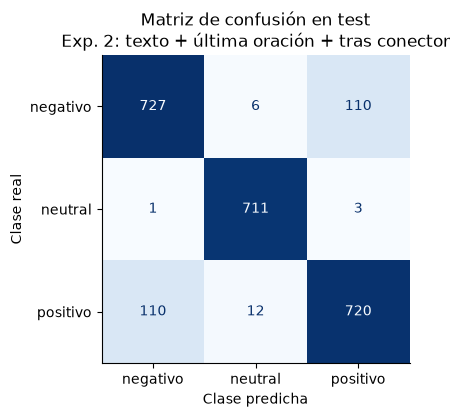

Accuracy negativo vs positivo en test -> exp. 1: 0.607 (experimento1.ipynb) | exp. 2: 0.859


In [13]:
metricas_e2 = evaluar_en_test(busqueda_e2.best_estimator_, "Exp. 2: texto + última oración + tras conector")

np_test = (y_test != "neutral").to_numpy()
acc_np_e2 = accuracy_score(y_test[np_test], metricas_e2["pred"][np_test])
print(f"Accuracy negativo vs positivo en test -> exp. 1: {REFERENCIA_E1['acc_neg_vs_pos_test']:.3f} "
      f"(experimento1.ipynb) | exp. 2: {acc_np_e2:.3f}")

In [14]:
top_coeficientes(busqueda_e2.best_estimator_)

,negativo,neutral,positivo
0,ultima__mal (3.89),texto__viene (2.76),tras_conector__resistente (3.25)
1,tras_conector__mal (3.83),texto__trae (2.62),tras_conector__sobresaliente (3.00)
2,tras_conector__pobre (3.36),texto__la caja (2.51),tras_conector__eficiente (2.99)
3,tras_conector__torpe (3.30),texto__kilo (2.10),tras_conector__notable (2.98)
4,ultima__inconsistente (3.19),texto__unidades (2.10),ultima__sobresaliente (2.98)
5,ultima__poco fiable (3.14),texto__paquete (2.08),ultima__espectacular (2.96)
6,tras_conector__terrible (3.09),texto__color (2.08),tras_conector__formidable (2.92)
7,tras_conector__poco fiable (3.05),texto__el paquete (1.99),tras_conector__espectacular (2.85)
8,ultima__pobre (2.99),texto__viene en (1.98),tras_conector__excelente (2.85)
9,tras_conector__endeble (2.96),texto__pesa (1.73),ultima__impecable (2.83)


### 2.6 Errores que quedan (sobre train, con predicciones de CV)

Para buscar ideas para los siguientes experimentos **no se miran los errores del test**: si el test guiara el diseño
de nuevas features, dejaría de ser una estimación honesta. En su lugar se usa `cross_val_predict` sobre `X_train`, que
predice cada reseña con un modelo entrenado en los otros folds (que no la vio). Se muestran reseñas
`negativo`/`positivo` mal clasificadas, oración por oración.

In [15]:
pred_cv_e2 = cross_val_predict(clone(busqueda_e2.best_estimator_), X_train, y_train, cv=skf, n_jobs=-1)

errores = (pred_cv_e2 != y_train.to_numpy()) & mascara_np
print(f"Errores negativo/positivo en CV: {errores.sum()} de {mascara_np.sum()} ({errores.sum() / mascara_np.sum():.1%})\n")

muestra = X_train[errores].sample(6, random_state=SEED)
for idx, texto in muestra.items():
    pred = pred_cv_e2[X_train.index.get_loc(idx)]
    print(f"[real: {y_train[idx]}  ->  predicho: {pred}]")
    for oracion in dividir_oraciones(texto):
        print("    ", oracion)
    print()

Errores negativo/positivo en CV: 1077 de 6739 (16.0%)

[real: positivo  ->  predicho: negativo]
     se lo compre a un familiar hace unos meses y llevo ya un tiempo usandolo en casa.
     la verdad, no volveria a comprar el cargador ni regalado.
     eso si, cada peso que pague por el material valio la pena.
     ahi queda mi experiencia con la compra.

[real: positivo  ->  predicho: negativo]
     me llego el pedido el martes pasado, tardo como tres dias.
     la carcasa me gusto bastante, se ve bien puesta en el celular.
     eso si, quede muy molesto con la señal, se me corta a cada rato.
     ni lo mejor ni lo peor la verdad.

[real: positivo  ->  predicho: neutral]
     me llego con la mensajeria de siempre, igual que cuando pedi otras cosas del hogar.
     lo compre un martes por la tarde sin mucha planificacion.
     de paso, la atencion al cliente me hizo la vida mas facil cuando llame a preguntar una duda.
     ya llevo un par de semanas usandolo en la cocina.

[real: positivo

### 2.7 Registro y envío

In [16]:
registrar_resultado(
    experimento=2,
    descripcion="TF-IDF (1,2) de texto completo + última oración + tras el último conector + LR",
    busqueda=busqueda_e2,
    metricas_test=metricas_e2,
    envio="submission_02.csv",
)

,experimento,descripcion,mejores_params,acc_train,acc_cv,std_cv,f1_cv,acc_test,f1_test,envio,kaggle_publico
0,1,"Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",{'clf__C': 10},0.9973,0.7364,0.0128,0.7478,0.7238,0.7366,submission_01.csv,None
1,2,"TF-IDF (1,2) de texto completo + última oración + tras el último conector + LR",{'clf__C': 10},0.9999,0.8865,0.0099,0.8908,0.8992,0.9031,submission_02.csv,None


In [17]:
envio_e2 = generar_envio(busqueda_e2, numero=2)

Envío guardado en envios/submission_02.csv y modelo en modelos/modelo_02.joblib
Distribución de predicciones en eval (%):
answer
negativo    35.4
neutral     28.4
positivo    36.2


### 2.8 Análisis del experimento 2

**Resultados:** accuracy de CV = **0,8865 ± 0,0099** (`C = 10`) y accuracy en test = **0,8992** (F1 macro 0,903),
frente a 0,7364 y 0,7238 del experimento 1: **+15 puntos en CV y +17,5 en test**.

1. **El problema principal quedó atacado:** entre `negativo` y `positivo` el test pasa de **60,7 % a 85,9 %**.
   Darle al final de la reseña su propia representación permite que una misma palabra pese distinto según su
   posición.
2. **Los coeficientes lo confirman:** las features con más peso hacia `negativo` y `positivo` son ahora casi todas de
   la última oración (`ultima__`) o del fragmento tras el conector (`tras_conector__`): `mal`, `pobre`, `terrible`
   frente a `resistente`, `sobresaliente`, `impecable`. `neutral` se sigue identificando con el texto completo
   (`texto__viene`, `texto__la caja`, `texto__voltios`), es decir, con vocabulario descriptivo.
3. **`neutral` se mantiene casi perfecta** (F1 0,985). La mejora no se logró a costa de esa clase.
4. **El test (0,899) queda algo por encima de la CV (0,887)**, dentro de lo esperable por la variación entre
   particiones; no hay señales de sobreajuste a la validación.
5. **Sobreajuste en train:** la accuracy de entrenamiento sigue en ≈ 1,0. Como en el experimento 1, la validación es
   casi plana entre `C = 3` y `C = 30` (0,885–0,887): la regularización no es el límite.

**Errores que quedan (sección 2.6, sobre train):** el 16 % de las reseñas `negativo`/`positivo` siguen mal
clasificadas. Los patrones que se observan:
- **La última oración es relleno o una evasiva** (*"ni lo mejor ni lo peor"*, *"ahí queda mi experiencia"*,
  *"ya llevo un par de semanas usándolo"*): el veredicto está en una oración anterior.
- **Conectores con distinto papel:** *"eso sí, …"* o *"por otro lado, …"* a veces introducen el veredicto y a veces
  solo un matiz secundario; el modelo no distingue el tipo de conector.
- **Opiniones sin conector en medio de texto descriptivo,** que el modelo confunde con `neutral`.
- Algunos casos parecen **ambiguos o con etiquetas discutibles**, lo que sugiere un techo de accuracy por debajo de
  100 %.

**Próximos pasos:** ajustar la representación sobre esta nueva base (experimento 3) y, más adelante, elegir la
**última oración con opinión** (saltando el relleno final) y codificar el **tipo de conector** (experimento 6).

### 2.9 Prueba de robustez: ¿qué pasa si el veredicto no está al final?

El experimento 2 aprovecha que en este conjunto de datos el veredicto suele estar al final de la reseña. En el
leaderboard privado esto no es un riesgo (público y privado son partes del mismo `eval.csv`, que tiene la misma
estructura que train, sección 5.4), pero si el modelo se usara con reseñas de otra fuente (por ejemplo, un
e-commerce real), donde muchas personas escriben el veredicto al inicio, la ventaja podría perderse o incluso
volverse en contra.

Para **medir** esa dependencia en lugar de suponerla, se alteran las reseñas del test y se comparan los dos modelos:

| Escenario | Qué se hace |
|---|---|
| Original | test sin cambios |
| Oraciones desordenadas | se permutan al azar las oraciones de cada reseña (semilla fija) |
| Última oración al inicio | la última oración pasa a ser la primera: simula a quien escribe el veredicto primero |

Como referencia se entrena **una sola vez** el pipeline de la línea base (TF-IDF (1,2) + LR con `C = 10`, la
configuración elegida en `experimento1.ipynb`) sobre `X_train`, sin CV ni envío. No se puede usar
`modelos/modelo_01.joblib` porque ese modelo se entrenó con las 12.000 reseñas, incluido el test.

No es leakage: el test solo se usa para reportar esta prueba, no para tomar decisiones de diseño.

In [18]:
def desordenar_oraciones(textos, seed=SEED):
    """Permuta al azar las oraciones de cada reseña (reproducible con la semilla)."""
    rng = np.random.default_rng(seed)
    salida = []
    for texto in textos:
        oraciones = dividir_oraciones(texto)
        salida.append(" ".join(rng.permutation(oraciones)) if len(oraciones) > 1 else texto)
    return pd.Series(salida, index=textos.index)


def ultima_al_inicio(textos):
    """Mueve la última oración al inicio de la reseña."""
    def mover(texto):
        oraciones = dividir_oraciones(texto)
        return " ".join([oraciones[-1]] + oraciones[:-1])
    return textos.map(mover)


ESCENARIOS = {
    "Original": X_test,
    "Oraciones desordenadas": desordenar_oraciones(X_test),
    "Última oración al inicio": ultima_al_inicio(X_test),
}

print("Ejemplo (oraciones desordenadas):")
print("  ANTES  :", X_test.iloc[0])
print("  DESPUÉS:", ESCENARIOS["Oraciones desordenadas"].iloc[0])

Ejemplo (oraciones desordenadas):
  ANTES  : la compre a inicios de mes y llego en tres dias a mi casa, en la caja original y todo. he de decir que la ergonomia me resulto ser redonda la verdad, se siente comoda cuando la agarro en el trabajo. la uso a diario para mis clases online. a fin de cuentas, la bateria se ve chapucera desde el primer dia, se nota el plastico flojo ahi atras.
  DESPUÉS: a fin de cuentas, la bateria se ve chapucera desde el primer dia, se nota el plastico flojo ahi atras. la uso a diario para mis clases online. he de decir que la ergonomia me resulto ser redonda la verdad, se siente comoda cuando la agarro en el trabajo. la compre a inicios de mes y llego en tres dias a mi casa, en la caja original y todo.


In [19]:
modelo_ref_e1 = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
    ("clf", LogisticRegression(C=10, max_iter=2000, random_state=SEED)),
]).fit(X_train, y_train)
modelo_e2 = busqueda_e2.best_estimator_

filas = []
for escenario, X_esc in ESCENARIOS.items():
    for nombre, modelo in [("Exp. 1 (bolsa de palabras)", modelo_ref_e1), ("Exp. 2 (final de la reseña)", modelo_e2)]:
        pred = modelo.predict(X_esc)
        filas.append({
            "escenario": escenario,
            "modelo": nombre,
            "accuracy": accuracy_score(y_test, pred),
            "acc negativo vs positivo": accuracy_score(y_test[np_test], pred[np_test]),
        })

robustez = pd.DataFrame(filas)
robustez.pivot(index="escenario", columns="modelo", values=["accuracy", "acc negativo vs positivo"]) \
    .reindex(list(ESCENARIOS)).round(4)

accuracy  \
modelo                   Exp. 1 (bolsa de palabras)   
escenario                                             
Original                                     0.7238   
Oraciones desordenadas                       0.7208   
Última oración al inicio                     0.7242   

                                                      \
modelo                   Exp. 2 (final de la reseña)   
escenario                                              
Original                                      0.8992   
Oraciones desordenadas                        0.6858   
Última oración al inicio                      0.5742   

                           acc negativo vs positivo  \
modelo                   Exp. 1 (bolsa de palabras)   
escenario                                             
Original                                     0.6071   
Oraciones desordenadas                       0.6030   
Última oración al inicio                     0.6071   

                                                      
modelo                   Exp. 2 (final de la reseña)  
escenario                                             
Original                                      0.8588  
Oraciones desordenadas                        0.5567  
Última oración al inicio                      0.3964

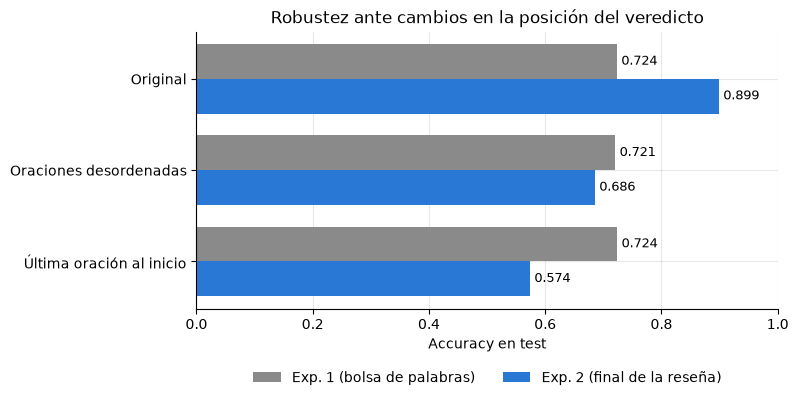

In [20]:
fig, ax = plt.subplots(figsize=(7.5, 3.6))
escenarios = list(ESCENARIOS)
y_pos = np.arange(len(escenarios))
alto = 0.38
for desplazamiento, (nombre, color) in zip([-alto / 2, alto / 2], [
        ("Exp. 1 (bolsa de palabras)", "#8a8a8a"), ("Exp. 2 (final de la reseña)", "#2a78d6")]):
    valores = robustez[robustez["modelo"] == nombre].set_index("escenario").loc[escenarios, "accuracy"]
    barras = ax.barh(y_pos + desplazamiento, valores, height=alto, color=color, label=nombre)
    ax.bar_label(barras, fmt="%.3f", padding=3, fontsize=9)

ax.set_yticks(y_pos, escenarios)
ax.invert_yaxis()
ax.set_xlim(0, 1)
ax.set_xlabel("Accuracy en test")
ax.set_title("Robustez ante cambios en la posición del veredicto")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False)
plt.show()

**Lectura de la prueba de robustez**

- **La línea base no cambia** (0,721–0,724): una bolsa de palabras no usa el orden, así que reordenar las oraciones
  casi no la afecta (solo cambian algunos bigramas que cruzan el límite entre oraciones).
- **El experimento 2 depende fuertemente de la posición:**
  - con las oraciones desordenadas cae de 0,899 a **0,686**, por debajo de la línea base;
  - con la última oración al inicio cae a **0,574**, y entre `negativo` y `positivo` a **0,396**, peor que el azar.
    Al mover el veredicto al inicio, la nueva última oración suele ser la opinión parcial de signo contrario, y el
    modelo, que aprendió a confiar en el final, predice justamente la clase opuesta.
- Esto confirma que la ganancia del experimento 2 viene de aprovechar **la estructura de este conjunto de datos**
  (el veredicto al final), no de "entender" el sentimiento en general. Además, como el modelo concentra el peso en
  las partes finales, cuando esa estructura no se cumple rinde **peor** que la línea base, no solo igual.

**Conclusión y decisión**
- **Para la competencia se mantiene el experimento 2:** el leaderboard (público y privado) sale de `eval.csv`, que
  tiene la misma estructura que train (sección 5.4). El score público de `submission_02` servirá como confirmación.
- **Limitación documentada:** este modelo **no** debería llevarse a reseñas de otra fuente (por ejemplo, un
  e-commerce real) sin validarlo antes con datos de esa fuente. En ese escenario sería más seguro el modelo de
  bolsa de palabras o, mejor, modelos que aprenden el orden de forma general en lugar de una regla de posición
  fija, como los modelos secuenciales de la Parte 2 (RNN, LSTM, transformers).
- Para los siguientes experimentos conviene preferir features que identifiquen el veredicto por su **contenido**
  (conectores como "al final", "en resumen") y no solo por su posición, y repetir esta prueba de robustez para
  medir el compromiso entre accuracy y robustez.